In [1]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

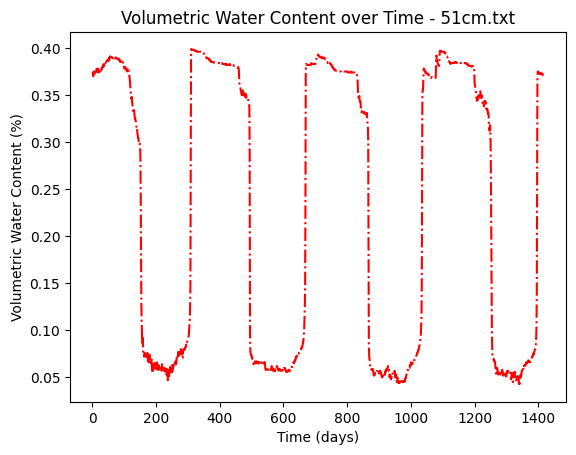

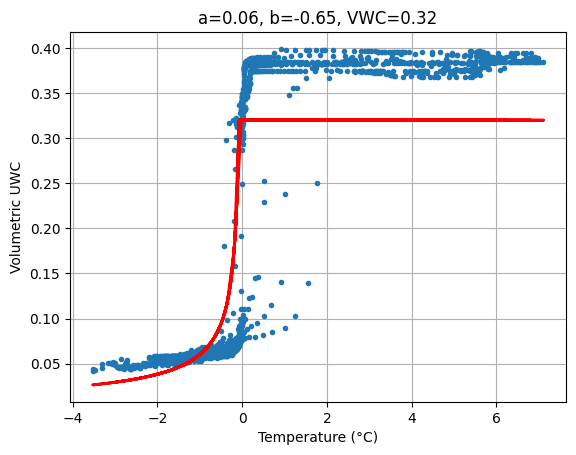

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def soilmoist(filename):
    """
    Function to read a file containing temperature and volumetric water content data,
    then plot the respective graphs.

    Parameters:
    filename (str): The name of the file containing the data.
    """
    # Load the data from the provided file
    m = np.loadtxt(filename)

    # Get the length of the data
    nn = len(m)

    # Plot 1: Volumetric water content vs. time
    plt.figure(1)
    plt.plot(range(1, nn+1), m[:, 1], 'r-.')
    plt.xlabel('Time (days)')
    plt.ylabel('Volumetric Water Content (%)')
    plt.title(f'Volumetric Water Content over Time - {filename}')

    # Plot 2: Volumetric water content vs. temperature
    plt.figure(2)
    plt.plot(m[:, 0], m[:, 1], '.')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Volumetric Water Content (%)')
    plt.grid(True)

    # Constants for volumetric soil moisture content
    a = 0.06
    b = -0.65
    varnod = 0.32 # volumetric porosity

    # Temperature and moisture calculation
    T = m[:, 0]
    t_f = -(varnod / a)**(1 / b) # freezing depression temp

    theta = np.zeros(len(T))

    for i in range(len(T)):
        if T[i] > t_f:
            theta[i] = varnod
        else:
            theta[i] = a * abs(T[i])**b

    # Plot 3: Volumetric unfrozen water function vs. temperature
    plt.plot(T, theta, '-r', linewidth=2)
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Volumetric UWC')
    plt.title(f'a={a}, b={b}, VWC={varnod}')
    plt.grid(True)

    # Show all plots
    plt.show()

# Example usage (uncomment to use):
soilmoist('51cm.txt')
